<a href="https://colab.research.google.com/github/BillieBurden/digital-history-2026/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('schools_cleaned_fixed.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   School             418 non-null    object
 1   State              418 non-null    object
 2   operation_dates    411 non-null    object
 3   tribes_identified  418 non-null    object
 4   DOI deceased       418 non-null    int64 
 5   WP deceased        418 non-null    int64 
 6   DOI burial sites   65 non-null     object
 7   WP burial sites    57 non-null     object
 8   other_names        362 non-null    object
 9   Latitude           404 non-null    object
 10  Longitude          404 non-null    object
 11  Verified           404 non-null    object
dtypes: int64(2), object(10)
memory usage: 39.3+ KB


In [4]:
df = df.dropna(subset=['operation_dates'])
df['operation_dates'] = df['operation_dates'].str.split('|')
df['operation_dates'] = df['operation_dates'].str[0]
df['operation_dates'] = df['operation_dates'].str.strip()


df['open_year'] = df['operation_dates'].str.split('-')
df['open_year'] = df['open_year'].str[0]
df['open_year'] = pd.to_numeric(df['open_year'], errors='coerce').astype(int)

df['close_year'] = df['operation_dates'].str.split('-')
df['close_year'] = df['close_year'].str[1].str.strip()

df['still_operating']= df['close_year'].str.lower() == 'open'
df['close_year'] = pd.to_numeric(df['close_year'], errors = 'coerce').fillna(2024).astype(int)

df[['School', 'operation_dates', 'open_year', 'close_year']].head(10)
print(f"Schools still operating: {df['still_operating'].sum()}")

Schools still operating: 84


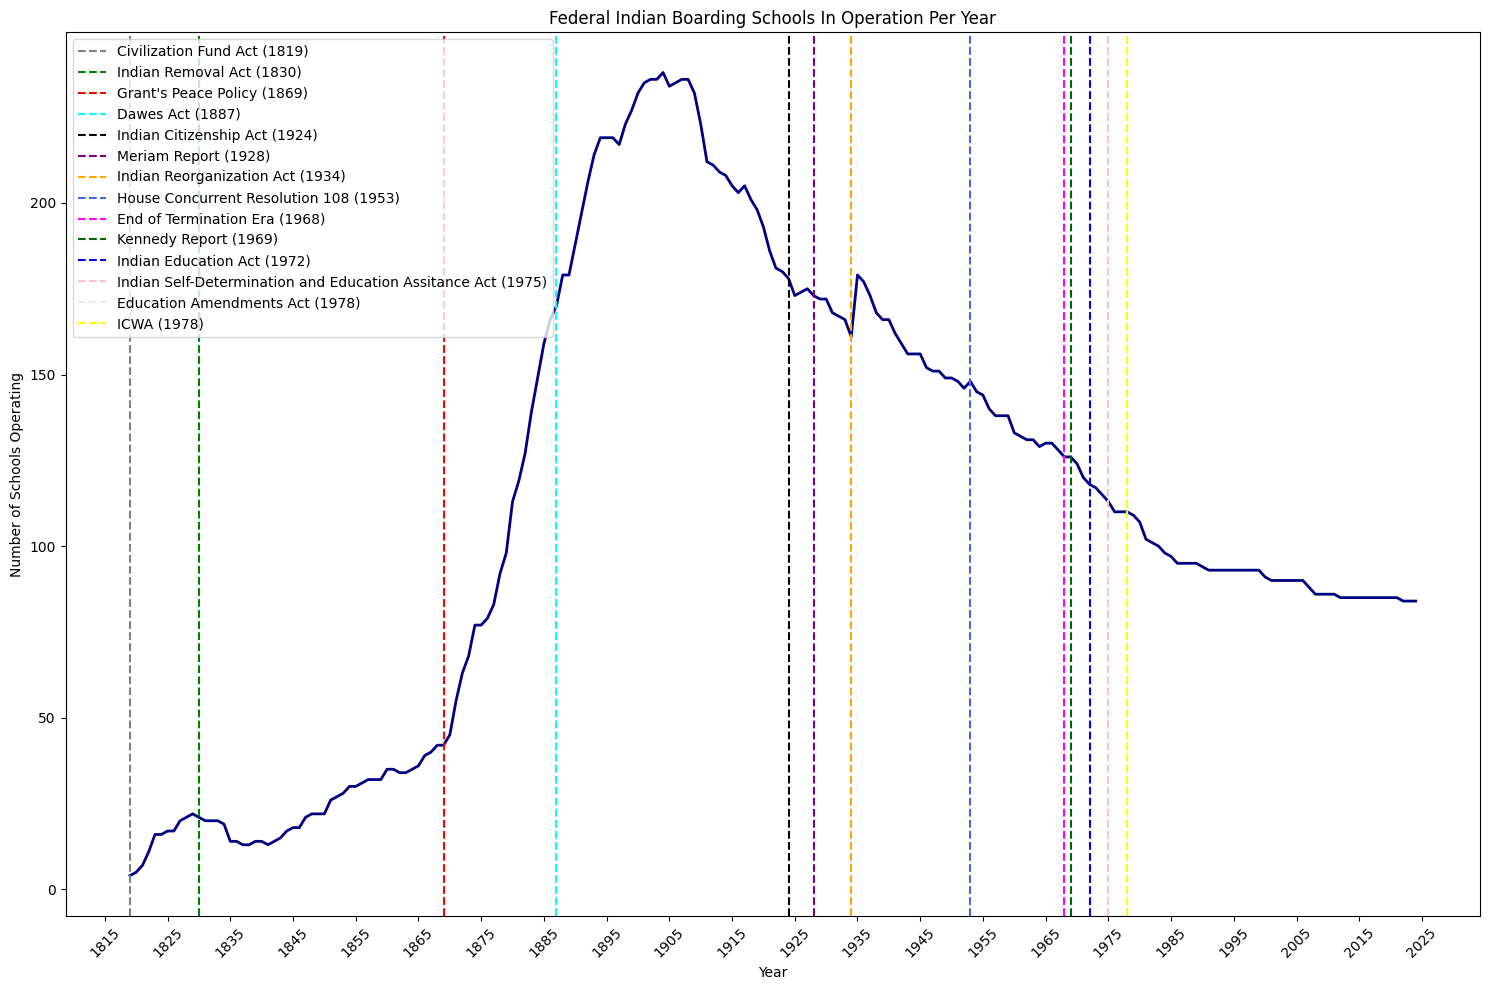

In [11]:

#creating a chart with number of schools active in each year between 1819 to 2024
#need list of every year we want to check
years= np.arange(1819, 2025)

#counting schools where open_year is at or before it and close_year is at or after it
operating_school_counts= []
for y in years:
  count= ((df['open_year'] <= y) & (df['close_year'] >= y)).sum()
  operating_school_counts.append(count)

#plotting it as a line chart for operating school
plt.figure(figsize=(15,10))
plt.plot(years, operating_school_counts, color= 'navy', linewidth=2)

#plot the policies here too. adding some earlier policies and events for greater context
plt.axvline(x=1819, color= 'gray', linestyle= '--', label= 'Civilization Fund Act (1819)')
plt.axvline(x=1830, color= 'green', linestyle= '--', label= 'Indian Removal Act (1830)')
plt.axvline(x=1869, color= 'red', linestyle='--', label= "Grant's Peace Policy (1869)")
plt.axvline(x= 1887, color= 'cyan', linestyle= '--', label= 'Dawes Act (1887)')
plt.axvline(x=1924, color= 'black', linestyle= '--', label= 'Indian Citizenship Act (1924)')
plt.axvline(x=1928, color= 'purple', linestyle= '--', label= 'Meriam Report (1928)')
plt.axvline(x=1934, color= 'orange', linestyle= '--', label= 'Indian Reorganization Act (1934)')
plt.axvline(x= 1953, color= 'royalblue', linestyle= '--', label= 'House Concurrent Resolution 108 (1953)')
plt.axvline(x=1968, color= 'fuchsia', linestyle= '--', label= 'End of Termination Era (1968)')
plt.axvline(x=1969, color= 'darkgreen', linestyle= '--', label= 'Kennedy Report (1969)')
plt.axvline(x=1972, color= 'blue', linestyle= '--', label= 'Indian Education Act (1972)')
plt.axvline(x=1975, color= 'pink', linestyle= '--', label= 'Indian Self-Determination and Education Assitance Act (1975)')
plt.axvline(x=1978, color= 'lavender', linestyle= '--', label= 'Education Amendments Act (1978)')
plt.axvline(x=1978, color= 'yellow', linestyle= '--', label= 'ICWA (1978)')

plt.title('Federal Indian Boarding Schools In Operation Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Schools Operating')
plt.legend(loc='upper left')
plt.xticks(np.arange(1815,2030, 10), rotation=45)

plt.tight_layout()
plt.show()

# The Graph
The chart above shows how many federal Indian boarding schools were in operation each year from 1819 through 2024. This is a different view than my Milestone 3, which only counted new openings. Counting active schools this way gives us a fuller lifespan of the boarding school system, including when it grew and when schools actually closed. This shape is more of what I expected than the one from my MVP. However, my MVP was an important step because it pushed me to take a closer look at the years of opening schools that went under my radar. Though I think this graph still proves that the 1930s has interesting activity while also displaying the more predictable rise and fall in schools.

# Explaining the chart and related historical events
The chart starts in 1819 because that is when Congress passed the Civilization Fund Act, which created an annual $10,000 appropriation aimed at destroying Native American culture through essentially rewiring Native children through education. Almost all of the money was given to Protestant and Catholic mission groups who were already operating schools in Native communities and were willing to perform the work the federal government did not have the capacity to do itself just yet. This is where historians most often point to as the official start of the boarding school system. Yet as shown in the chart, it didn't truly take off until the 1860s.

The other major event between 1819 and 1860s is the Indian Removal Act of 1830, which forced tribes living east of the Mississippi to move to what the government called Indian Territory, present-day Oklahoma. Around this time, we see a smaller bump in numbers going up to 22 in 1829 then dropping down to 14 by 1835. The Trail of Tears happening in the late 1830s could be the reason for the pattern we see. The schools that had been operating in the 1820s were growing until the Native people were forced to move west, ultimately leading to the closing of the schools. There is a curious dip at 1835 that further research led me to the Treaty of New Echota, which was signed that year. This was the corrupt legal basis for Cherokee removal that became the Trail of Tears in 1838 ("Treaty of New Echota"). And even before this, many tribes including the Choctaw, Shawnee, and Chickasaw had already signed treaties and been forced to leave ("Timeline of Removal"). So during these years I would expect schools to be increasingly losing their students thus having increasing closures.

Like I said, the boarding schools really started to surge in the 1860s. The Peace Policy in 1869 has a strong connection to this. The policy turned over the administration of Indian reservations to Christian denominations. Similarly to 1819, Congress set aside funds for these churches and missionaries to build and run school facilities (NABS). Yet this time, funding was even more formalized and the amount scaled up significantly. In the graph we can see how the system changed if we look at before 1869 where there were fewer than 50 schools operating then if we look at 1887 where there are more than triple that. It was also during these years that the slogan "Kill the Indian, Save the Man" became the guiding logic after the first off-reservation school opened in 1879, Carlisle School (NABS). Carlisle's founder Richard Henry Pratt argued that reservation schools failed because students returned home to their families, so he proposed that schools should take children far from home and keep them there for years.

This leads me to the peak between ~1887 and 1928. Firstly, the Dawes Act, also called the General Allotment Act passed in 1887. It was a land policy and not an education policy that broke up reservation land into 160-acre plots assigned to individual Native heads of households. The goal was to dissolve the collective tribal land and force assimilation through private property ownership ("Dawes Act"). But the boarding schools grew alongside it because the government's objectives were all the same. Take the land, take the children, and reshape them to meet their needs. The years following the Dawes Act are also within the peak of the chart. Active schools rose from 170 in 1887 to the highest number, 238, in 1904. The count stayed above 230 for nearly a decade. After 1910, there was a slow decline, but it still maintained very high numbers. By 1920 there were still over 200 active boarding schools and by 1928 there were 173. This shows just how stable this system had become instead of just being experimental.

The Meriam Report in 1928 is where a shift began. The report, commissioned by the federal government, was the first official acknowledgement that the boarding school system was failing. It documented overcrowding, malnutrition, inadequate medical care, harsh disciplining, and underqualified teachers ("American Indian Boarding School"). The Meriam report didn't directly close any schools and the chart shows that there was still a slow decline in numbers, but it helped influence federal opinion and push for the policy change in 1934.

So this brings us to the Indian Reorganization Act (IRA) or the Indian New Deal which passed in 1934, which is also where I was most surprised in milestone 3. It was directly informed by the Meriam Report and made an attempt to undo decades of assimilation policies. The IRA ended the Dawes Act's land allotment system and gave tribes the right to organize their own governments ("Indian New Deal"). John Collier, who was the new commissioner of the Bureau of Indian Affairs, wanted to close large off-reservation boarding schools and replace them with smaller community day schools built on tribal land where children could live at home with their families ("Indian New Deal").

Again, this is where I saw numbers that initially surprised me because I expected the IRA to end the boarding school system.
However, looking at milestone 3 and this graph, we see a drop in schools from 172 to 161 from 1930 to 1934 and 6 more closing by the end of 1934. Then, we see the number rise back up to 179 in 1935. It's not a big shift and it definitely isn't as shocking as my milestone 3 made it look but there is still meaningful history happening. If Collier had been able to close the old boarding schools as fast as he wanted, I would expect there to be a bigger drop. There are two reasons he was slowed down. First, the Great Depression. It hit Native communities hard especially given that poverty on reservations was already high and many Native families relied on seasonal wage labor that went away during the Depression (Child). Brenda Child argues that Native families sometimes turned to boarding schools because they could provide basic necessities such as food, shelter, and clothing that families struggled to provide themselves (Child). When families were depending on these schools to survive, Collier could not just shut them down. Second, the new school system Collier advocated for mostly went up on the Navajo Nation. The Navajo Reservation was the largest tribal land in the country and Collier thought it was an optimal place to test his projects (SAH Archipedia). The project was funded by the Public Works Administration as a part of New Deal jobs programs (SAH Archipedia). He intended that these schools would refocus towards native culture, language, and community-based education. So although the numbers show that new schools were opening, it's necessary to understand that these were a shift away from the old boarding school system. But keep in mind, most of the schools operating during these years had been open since before 1935, so the IRA didn't immediately reform them or reform them at all.

After the spike in 1935 the chart starts to show a long decline. The numbers dropped from 149 in 1950 to 97 in 1985, but again, it was not an immediate drop, showing that there was not just one event that ended the operation of these schools. And even during this downward trend, there was a push to bring education back to consist of assimilation. The 1950s is known as the termination era. This is because Congress passed the House Concurrent Resolution 108, which essentially had the goal of ending tribes as separate political entities, pushing Native people to live more conventional urban lives (Department of Diné Education). This policy also led over a hundred tribes to lose their tribal status and over a million acres of land were taken (UAF Tribal Governance). Alongside termination, the BIA also introduced a Relocation Program that moved Native people away from reservations to city life as a way to combat the growing unemployment rates. By 1960, more than 33,000 people had been relocated (UAF Tribal Governance). In addition to this, the government also ran the Indian Adoption Project which placed Native children with non-Native (white) families (Kids Matter Inc.). It is a similar philosophy to the boarding schools but in a different form and taking away cultural and familial ties completely. The termination era ended in 1968 with the 1969 Kennedy Report on Indian education following it a year later. This report combined with other Native activism in the 60s and 70s pushed Congress to implement change in who controlled boarding schools and Native schools in general (Department of Diné Education). The Indian Education Act of 1972 was the first big step. It funded new educational programs and gave tribes more say in public schools (Department of Diné Education). Three years later, the Indian Self-Determination and Education Assistance Act of 1975 finally let tribes take over the federally run schools (Department of Diné Education). Then, in 1978 two major laws added to the progress. First, The Education Amendments Act of 1978 reformed the BIA's school system by setting new education standards and requiring tribal and parental involvement in school decisions (Bureau of Indian Affairs). Second, the Indian Child Welfare Act of 1978 gave Native parents the legal right to refuse a child's placement and required tribal involvement in custody cases (Kids Matter Inc.). This was the first time tribes had actual authority over their citizens and their children.

Finally, looking past 1978, we see the graph start to tail off and now we have around 84 schools that were still in operation as of 2024. Though they are not operating like the old boarding schools. They are mostly run by the tribes themselves primarily under federal funding for the purpose of providing "quality education opportunities from early childhood onward in accordance with a tribe's needs for cultural and economic well-being, in keeping with the wide diversity of Indian tribes and Alaska Native villages as distinct cultural and governmental entities." (Bureau of Indian Affairs).




# Citations
"American Indian Boarding School." Encyclopaedia Britannica, www.britannica.com/topic/American-Indian-boarding-school. Accessed 25 Apr. 2026.

"Boarding Schools and the History of ICWA." Kids Matter Inc., 9 May 2023, www.kidsmatterinc.org/legal-help/native-american-children/boarding-schools-and-the-history-of-icwa/. Accessed 25 Apr. 2026.

"Bureau of Indian Education." Bureau of Indian Affairs, U.S. Department of the Interior, www.bia.gov/bie. Accessed 28 Apr. 2026.
Child, Brenda J. Boarding School Seasons: American Indian Families, 1900-1940. University of Nebraska Press, 1998.

"The Dawes Act." National Park Service, U.S. Department of the Interior, 9 July 2021, www.nps.gov/articles/000/dawes-act.htm. Accessed 25 Apr. 2026.
Department of Diné Education. Historical Timeline of Diné Education. Navajo Nation, Jan. 2015, edited Apr. 2018. PDF.

"Implementation of New Indian Education Act Has Begun." Bureau of Indian Affairs, 9 Nov. 1978, www.bia.gov/as-ia/opa/online-press-release/implementation-new-indian-education-act-has-begun. Accessed 27 Apr. 2026.

"Indian New Deal." EBSCO Research Starters, www.ebsco.com/research-starters/politics-and-government/indian-new-deal. Accessed 27 Apr. 2026.

National Native American Boarding School Healing Coalition. "US Indian Boarding School History." NABS, boardingschoolhealing.org/us-indian-boarding-school-history/. Accessed 25 Apr. 2026.

"Termination Era, the 1950s, Public Law 280." Tribal Governance, University of Alaska Fairbanks, www.uaf.edu/tribal/academics/112/unit-2/terminationerathe1950spubliclaw280.php. Accessed 27 Apr. 2026.

"Timeline of Removal." Oklahoma Historical Society, www.okhistory.org/research/removal. Accessed 27 Apr. 2026.

Tippeconnic Fox, Jason, and Mary Jo Tippeconnic Fox. "Navajo Nation Council Chamber." SAH Archipedia, edited by Gabrielle Esperdy and Karen Kingsley, University of Virginia Press, 2012, sah-archipedia.org/buildings/AZ-01-001-0054. Accessed 25 Apr. 2026.

"The Treaty of New Echota and the Trail of Tears." North Carolina Department of Natural and Cultural Resources, 29 Dec. 2016, www.dncr.nc.gov/blog/2016/12/29/treaty-new-echota-and-trail-tears. Accessed 25 Apr. 2026.